In [1]:
# DAY 5: MODEL EVALUATION & SELECTION (IMPROVED)
# UCI Heart Disease Prediction
# PURPOSE:
#   - Load trained models from the Day 4 manifest
#   - Evaluate all models consistently on the held-out test set
#   - Create comparison table of all metrics
#   - Identify the best model by weighted F1 score

import pandas as pd
import numpy as np
import json
import os
import pickle
import sys
from datetime import datetime

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('scripts')
from utils import evaluate_classifier, create_model_comparison_report, load_model


In [2]:
# SECTION 1: LOAD DATA & MODELS

print("LOADING DATA AND TRAINED MODELS")

# Load test data saved by Day 4
X_test = pd.read_csv('outputs/X_test.csv')
y_test = pd.read_csv('outputs/y_test.csv').squeeze()

# Load only the models produced by the latest Day 4 notebook run.
# This avoids accidentally evaluating stale models left over from older experiments.
manifest_path = 'outputs/reports/day4_model_manifest.json'
trained_models = {}

if os.path.exists(manifest_path):
    with open(manifest_path, 'r') as f:
        model_manifest = json.load(f)

    for model_name, model_path in model_manifest.items():
        trained_models[model_name] = load_model(model_path)
else:
    print("⚠ Model manifest not found. Falling back to all *_trained.pkl files.")
    model_files = [f for f in os.listdir('outputs/models') if f.endswith('_trained.pkl')]
    for model_file in model_files:
        model_name = model_file.replace('_trained.pkl', '')
        trained_models[model_name] = load_model(f'outputs/models/{model_file}')

print(f"✓ Loaded {len(trained_models)} models")
for model_name in trained_models:
    print(f"  • {model_name}")


LOADING DATA AND TRAINED MODELS
✓ Loaded 22 models
  • dummy_baseline
  • logistic_regression
  • ridge_classifier
  • sgd_classifier
  • perceptron
  • knn
  • gaussian_nb
  • linear_svm
  • svm_rbf
  • decision_tree
  • random_forest
  • extra_trees
  • bagging
  • adaboost
  • gradient_boosting
  • hist_gradient_boosting
  • linear_discriminant_analysis
  • nearest_centroid
  • xgboost
  • lightgbm
  • catboost
  • random_forest_random_search


In [3]:
# SECTION 2: EVALUATE ALL MODELS

print("EVALUATING ALL MODELS")

evaluation_results = {}

for model_name, model in trained_models.items():
    print(f"\n▶ Evaluating {model_name}...", end=" ")

    try:
        evaluation_results[model_name] = evaluate_classifier(model, X_test, y_test)
        print("✓ Done")

    except Exception as e:
        print(f"✗ Failed: {str(e)[:80]}")
        continue


EVALUATING ALL MODELS

▶ Evaluating dummy_baseline... ✓ Done

▶ Evaluating logistic_regression... ✓ Done

▶ Evaluating ridge_classifier... ✓ Done

▶ Evaluating sgd_classifier... ✓ Done

▶ Evaluating perceptron... ✓ Done

▶ Evaluating knn... ✓ Done

▶ Evaluating gaussian_nb... ✓ Done

▶ Evaluating linear_svm... ✓ Done

▶ Evaluating svm_rbf... ✓ Done

▶ Evaluating decision_tree... ✓ Done

▶ Evaluating random_forest... ✓ Done

▶ Evaluating extra_trees... ✓ Done

▶ Evaluating bagging... ✓ Done

▶ Evaluating adaboost... ✓ Done

▶ Evaluating gradient_boosting... ✓ Done

▶ Evaluating hist_gradient_boosting... ✓ Done

▶ Evaluating linear_discriminant_analysis... ✓ Done

▶ Evaluating nearest_centroid... ✓ Done

▶ Evaluating xgboost... ✓ Done

▶ Evaluating lightgbm... ✓ Done

▶ Evaluating catboost... ✓ Done

▶ Evaluating random_forest_random_search... ✓ Done


In [4]:
# SECTION 3: CREATE MODEL COMPARISON TABLE

print("MODEL COMPARISON TABLE")

comparison_df = create_model_comparison_report(evaluation_results)

print("\n" + comparison_df.to_string())

# Save comparison table
comparison_df.to_csv('outputs/reports/model_comparison_table.csv')
print("\n✓ Saved: model_comparison_table.csv")


MODEL COMPARISON TABLE

                              accuracy precision    recall  f1_score   roc_auc
hist_gradient_boosting         0.61413  0.607185   0.61413  0.609553  0.829275
gradient_boosting              0.61413  0.575094   0.61413  0.592593  0.832158
xgboost                       0.592391  0.569685  0.592391  0.579736  0.844534
bagging                       0.592391  0.566997  0.592391  0.579017  0.832272
random_forest_random_search   0.603261   0.55803  0.603261  0.578356   0.85721
catboost                      0.597826  0.551134  0.597826  0.573432  0.851393
nearest_centroid              0.554348  0.606586  0.554348  0.569523  0.826875
lightgbm                      0.581522  0.554271  0.581522  0.566414  0.827527
logistic_regression           0.586957  0.542873  0.586957  0.561464  0.846802
linear_discriminant_analysis  0.570652  0.551698  0.570652  0.558547  0.841345
random_forest                 0.586957  0.533592  0.586957  0.558457   0.85703
svm_rbf                     

In [5]:
# SECTION 4: IDENTIFY BEST MODEL

print("BEST MODEL SELECTION")

# Select best model based on F1 score (you can change this metric)
best_model_name = comparison_df['f1_score'].idxmax()
best_model_metrics = comparison_df.loc[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name.upper()}")
print(f"\nPerformance Metrics:")
for metric, value in best_model_metrics.items():
    print(f"  • {metric.replace('_', ' ').title():20s}: {value:.4f}")


BEST MODEL SELECTION

🏆 BEST MODEL: HIST_GRADIENT_BOOSTING

Performance Metrics:
  • Accuracy            : 0.6141
  • Precision           : 0.6072
  • Recall              : 0.6141
  • F1 Score            : 0.6096
  • Roc Auc             : 0.8293


In [6]:
# SECTION 5: DETAILED ANALYSIS OF BEST MODEL

print(f"DETAILED ANALYSIS: {best_model_name.upper()}")

best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))

DETAILED ANALYSIS: HIST_GRADIENT_BOOSTING

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        82
           1       0.60      0.53      0.56        53
           2       0.35      0.36      0.36        22
           3       0.33      0.33      0.33        21
           4       0.20      0.17      0.18         6

    accuracy                           0.61       184
   macro avg       0.45      0.45      0.45       184
weighted avg       0.61      0.61      0.61       184



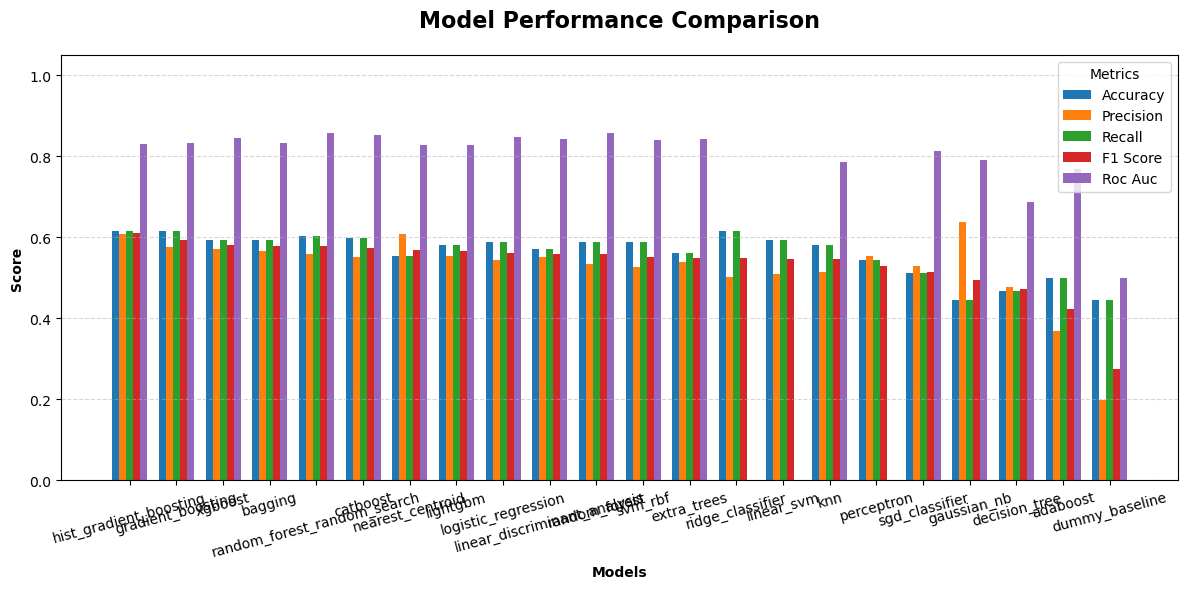

In [7]:
# GROUPED BAR CHART - MODEL COMPARISON

fig, ax = plt.subplots(figsize=(12, 6))

# Metrics to compare
metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']

# X-axis positions
x = np.arange(len(comparison_df.index))

# Width of each bar
width = 0.15

# Plot bars for each metric
for i, metric in enumerate(metrics):

    ax.bar(
        x + i * width,
        comparison_df[metric],
        width=width,
        label=metric.replace('_', ' ').title()
    )

# Title and labels
ax.set_title(
    'Model Performance Comparison',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Models', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')

# X ticks
ax.set_xticks(x + width * 2)
ax.set_xticklabels(comparison_df.index, rotation=15)

# Y range
ax.set_ylim(0, 1.05)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
ax.legend(title='Metrics')

plt.tight_layout()


In [8]:

fig.savefig(
    'outputs/visualizations/day5_model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: day5_model_comparison.png")

plt.show()
plt.close(fig)

✓ Saved: day5_model_comparison.png


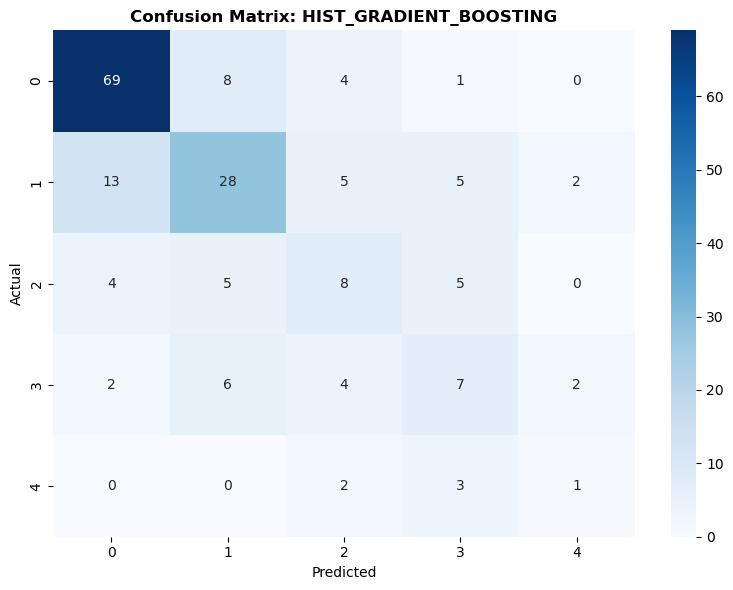

In [9]:
# 2. Confusion Matrix for Best Model
fig, ax = plt.subplots(figsize=(8, 6))
cm = np.array(evaluation_results[best_model_name]['confusion_matrix'])
class_labels = sorted(y_test.unique())
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=ax
)
ax.set_title(f'Confusion Matrix: {best_model_name.upper()}', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()


In [10]:
fig.savefig('outputs/visualizations/day5_best_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: day5_best_model_confusion_matrix.png")
plt.close()

✓ Saved: day5_best_model_confusion_matrix.png


In [11]:
# SECTION 7: SAVE EVALUATION REPORT

print("SAVING EVALUATION REPORT")

evaluation_report = {
    'evaluation_date': datetime.now().isoformat(),
    'models_evaluated': len(evaluation_results),
    'model_list': list(evaluation_results.keys()),
    'best_model': best_model_name,
    'best_model_metrics': {
        metric: (None if pd.isna(value) else float(value))
        for metric, value in best_model_metrics.items()
    },
    'all_model_metrics': {
        model: {
            k: (None if pd.isna(v) else float(v))
            for k, v in metrics.items()
            if k != 'confusion_matrix'
        }
        for model, metrics in evaluation_results.items()
    }
}

with open('outputs/reports/day5_evaluation_report.json', 'w') as f:
    json.dump(evaluation_report, f, indent=2)

print("✓ Saved: day5_evaluation_report.json")


SAVING EVALUATION REPORT
✓ Saved: day5_evaluation_report.json


In [12]:
# SECTION 8: SUMMARY

print("EVALUATION SUMMARY")
print(f"\nModels Evaluated      : {len(evaluation_results)}")
print(f"Best Model            : {best_model_name}")
print(f"Best Model F1 Score   : {best_model_metrics['f1_score']:.4f}")
print(f"Best Model Accuracy   : {best_model_metrics['accuracy']:.4f}")

EVALUATION SUMMARY

Models Evaluated      : 22
Best Model            : hist_gradient_boosting
Best Model F1 Score   : 0.6096
Best Model Accuracy   : 0.6141
